# Are you happy if you listen to k-pop?
This project is made to generate charts about [Music & Mental Health Survey Results](https://www.kaggle.com/datasets/catherinerasgaitis/mxmh-survey-results) from Kaggle

# Requirements

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Import data

In [13]:
df = pd.read_csv('mxmh_survey_results.csv')

display(df.head())
display(df.info())
display(df.describe())

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.


<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Timestamp                     736 non-null    str    
 1   Age                           735 non-null    float64
 2   Primary streaming service     735 non-null    str    
 3   Hours per day                 736 non-null    float64
 4   While working                 733 non-null    str    
 5   Instrumentalist               732 non-null    str    
 6   Composer                      735 non-null    str    
 7   Fav genre                     736 non-null    str    
 8   Exploratory                   736 non-null    str    
 9   Foreign languages             732 non-null    str    
 10  BPM                           629 non-null    float64
 11  Frequency [Classical]         736 non-null    str    
 12  Frequency [Country]           736 non-null    str    
 13  Frequency [EDM] 

None

,Age,Hours per day,BPM,Anxiety,Depression,Insomnia,OCD
count,735.000000,736.000000,6.290000e+02,736.000000,736.000000,736.000000,736.000000
mean,25.206803,3.572758,1.589948e+06,5.837636,4.796196,3.738451,2.637228
std,12.054970,3.028199,3.987261e+07,2.793054,3.028870,3.088689,2.842017
min,10.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000
25%,18.000000,2.000000,1.000000e+02,4.000000,2.000000,1.000000,0.000000
50%,21.000000,3.000000,1.200000e+02,6.000000,5.000000,3.000000,2.000000
75%,28.000000,5.000000,1.440000e+02,8.000000,7.000000,6.000000,5.000000
max,89.000000,24.000000,1.000000e+09,10.000000,10.000000,10.000000,10.000000


In [16]:
# Changer les fréquences d'écoutes en int
mapping = {
    'Never': 0,
    'Rarely': 1,
    'Sometimes': 2,
    'Very frequently': 3
}
columns = ['Frequency [Classical]',
       'Frequency [Country]', 'Frequency [EDM]', 'Frequency [Folk]',
       'Frequency [Gospel]', 'Frequency [Hip hop]', 'Frequency [Jazz]',
       'Frequency [K pop]', 'Frequency [Latin]', 'Frequency [Lofi]',
       'Frequency [Metal]', 'Frequency [Pop]', 'Frequency [R&B]',
       'Frequency [Rap]', 'Frequency [Rock]', 'Frequency [Video game music]']

for column in columns:
    df[column] = df[column].map(mapping)
df[columns].info()
df[columns].head()

<class 'pandas.DataFrame'>
RangeIndex: 736 entries, 0 to 735
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype
---  ------                        --------------  -----
 0   Frequency [Classical]         736 non-null    int64
 1   Frequency [Country]           736 non-null    int64
 2   Frequency [EDM]               736 non-null    int64
 3   Frequency [Folk]              736 non-null    int64
 4   Frequency [Gospel]            736 non-null    int64
 5   Frequency [Hip hop]           736 non-null    int64
 6   Frequency [Jazz]              736 non-null    int64
 7   Frequency [K pop]             736 non-null    int64
 8   Frequency [Latin]             736 non-null    int64
 9   Frequency [Lofi]              736 non-null    int64
 10  Frequency [Metal]             736 non-null    int64
 11  Frequency [Pop]               736 non-null    int64
 12  Frequency [R&B]               736 non-null    int64
 13  Frequency [Rap]               736 non-null    

,Frequency [Classical],Frequency [Country],Frequency [EDM],Frequency [Folk],Frequency [Gospel],Frequency [Hip hop],Frequency [Jazz],Frequency [K pop],Frequency [Latin],Frequency [Lofi],Frequency [Metal],Frequency [Pop],Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music]
0,1,0,1,0,0,2,0,3,3,1,0,3,2,3,0,2
1,2,0,0,1,2,1,3,1,2,1,0,2,2,1,3,1
2,0,0,3,0,0,1,1,3,0,2,2,1,0,1,1,3
3,2,0,0,1,2,0,3,2,3,2,0,2,2,0,0,0
4,0,0,1,0,1,3,0,3,2,2,0,2,3,3,0,1


In [17]:
# Création de la colonne Mental Health (somme des 4 scores)
df['Mental Health'] = df['Anxiety'] + df['Depression'] + df['Insomnia'] + df['OCD']

print(df[['Anxiety', 'Depression', 'Insomnia', 'OCD', 'Mental Health']].head(8))

df.to_csv('mxmh_survey_results_updated.csv', index=False)
display(df.head())

   Anxiety  Depression  Insomnia  OCD  Mental Health
0      3.0         0.0       1.0  0.0            4.0
1      7.0         2.0       2.0  1.0           12.0
2      7.0         7.0      10.0  2.0           26.0
3      9.0         7.0       3.0  3.0           22.0
4      7.0         2.0       5.0  9.0           23.0
5      8.0         8.0       7.0  7.0           30.0
6      4.0         8.0       6.0  0.0           18.0
7      5.0         3.0       5.0  3.0           16.0


,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions,Mental Health
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,3,0,2,3.0,0.0,1.0,0.0,NaN,I understand.,4.0
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,1,3,1,7.0,2.0,2.0,1.0,NaN,I understand.,12.0
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,1,1,3,7.0,7.0,10.0,2.0,No effect,I understand.,26.0
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,0,0,0,9.0,7.0,3.0,3.0,Improve,I understand.,22.0
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,3,0,1,7.0,2.0,5.0,9.0,Improve,I understand.,23.0


In [ ]:
sns.pairplot(df)
plt.show()

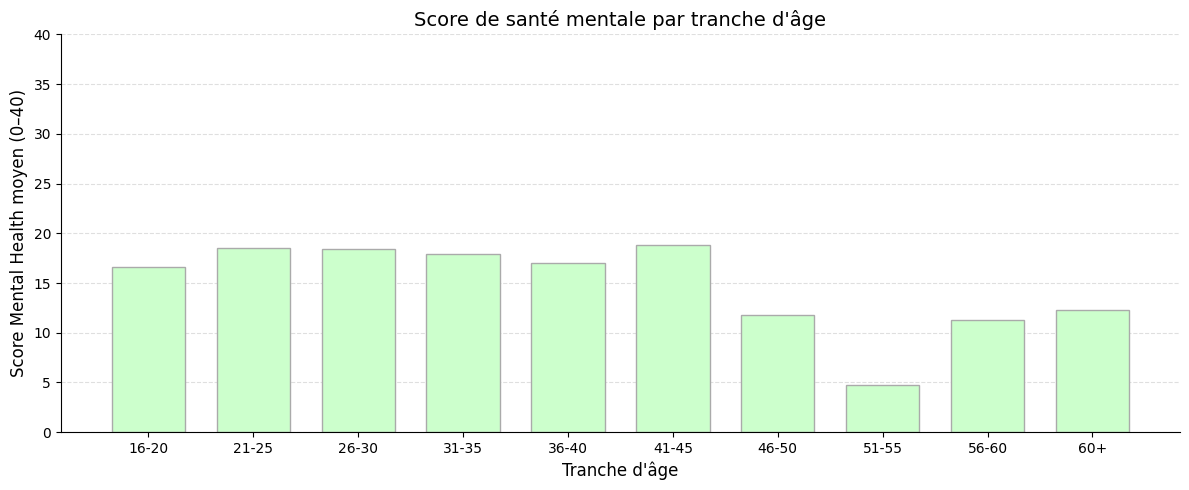

In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.bar(
    age_stats['Age Group'],
    age_stats['Mean Mental Health'],
    color='#ccffcc',
    edgecolor='#aaaaaa',
    width=0.7
)

ax.set_facecolor('white')
fig.patch.set_facecolor('white')
ax.set_xlabel("Tranche d'âge", fontsize=12)
ax.set_ylabel('Score Mental Health moyen (0–40)', fontsize=12)
ax.set_title("Score de santé mentale par tranche d'âge", fontsize=14)
ax.set_ylim(0, 40)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

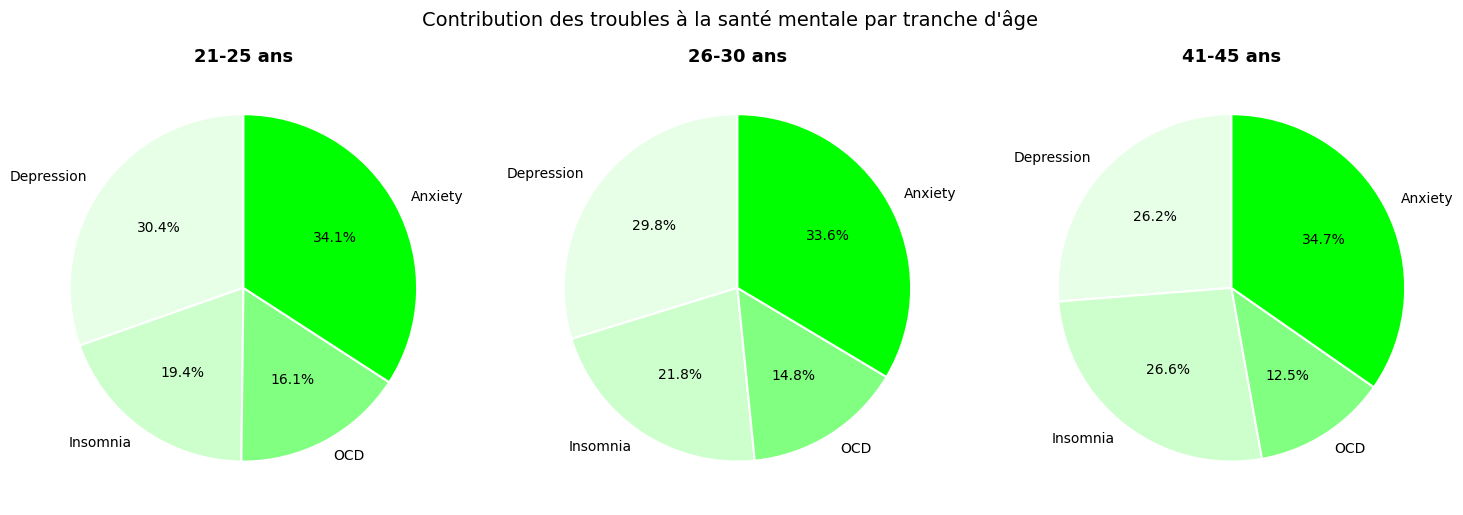

In [14]:
tranches = ['21-25', '26-30', '41-45']
colonnes = ['Depression', 'Insomnia', 'OCD', 'Anxiety']
couleurs = ['#e6ffe6', '#ccffcc', '#80ff80', '#00ff00']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.patch.set_facecolor('white')

for ax, tranche in zip(axes, tranches):
    groupe = df[df['Age Group'] == tranche][colonnes].mean()
    
    wedges, texts, autotexts = ax.pie(
        groupe,
        labels=colonnes,
        colors=couleurs,
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    ax.set_title(f'{tranche} ans', fontsize=13, fontweight='bold')

plt.suptitle("Contribution des troubles à la santé mentale par tranche d'âge", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

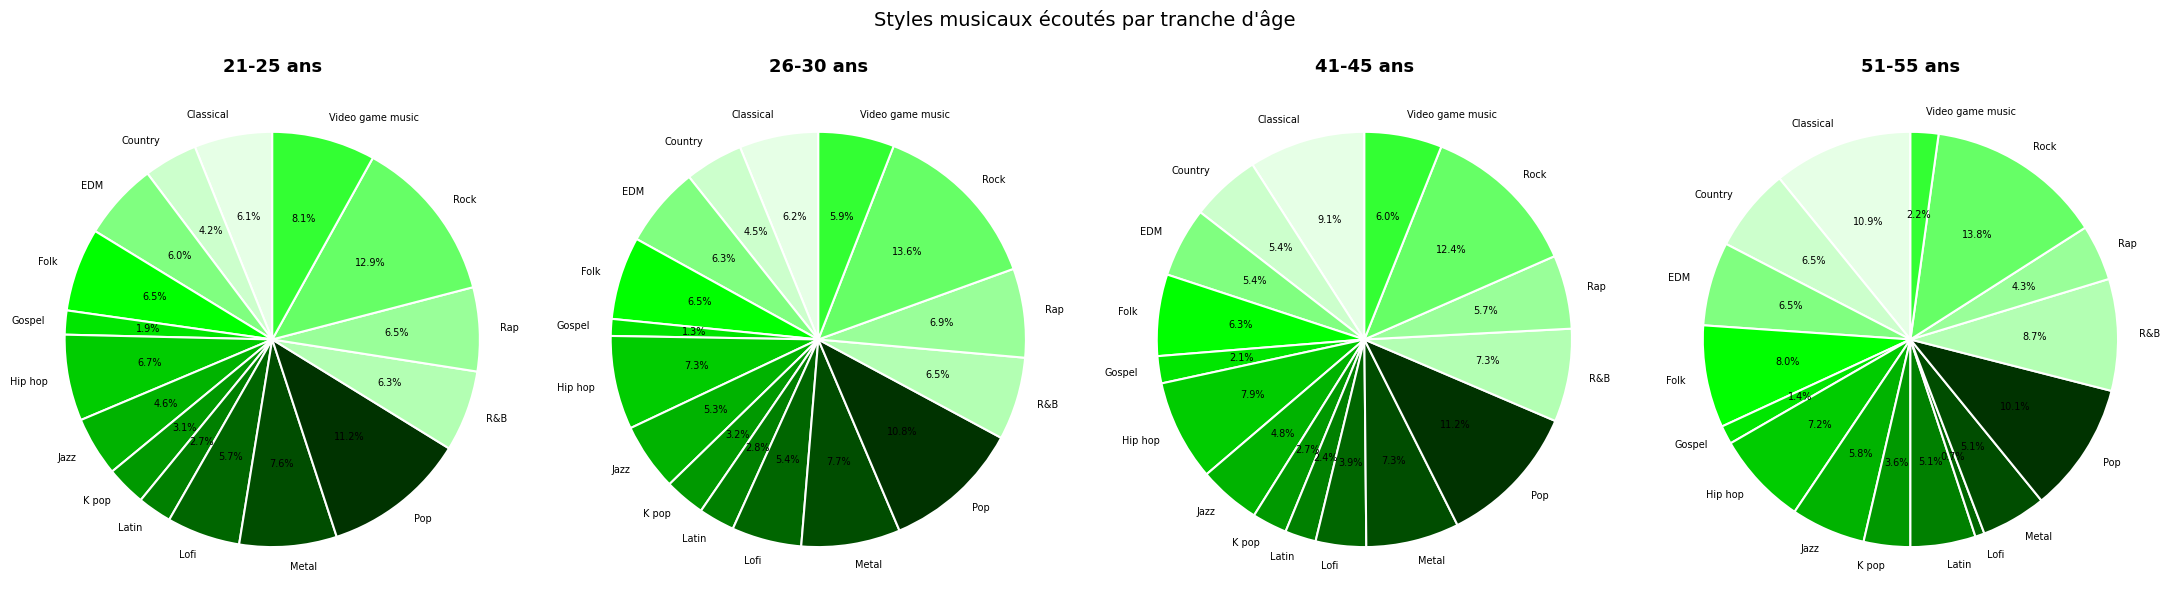

In [15]:
tranches = ['21-25', '26-30', '41-45', '51-55']
freq_cols = [col for col in df.columns if 'Frequency' in col]
genre_labels = [col.replace('Frequency [', '').replace(']', '') for col in freq_cols]

freq_map = {'Never': 0, 'Rarely': 1, 'Sometimes': 2, 'Frequently': 3, 'Very frequently': 4}
for col in freq_cols:
    df[col] = df[col].map(freq_map)

couleurs = ['#e6ffe6', '#ccffcc', '#80ff80', '#00ff00', '#00e600', '#00cc00', '#00b300',
            '#009900', '#008000', '#006600', '#004d00', '#003300', '#b3ffb3', '#99ff99',
            '#66ff66', '#33ff33']

fig, axes = plt.subplots(1, 4, figsize=(22, 6))
fig.patch.set_facecolor('white')

for ax, tranche in zip(axes, tranches):
    groupe = df[df['Age Group'] == tranche][freq_cols].mean()
    groupe.index = genre_labels

    ax.pie(
        groupe,
        labels=genre_labels,
        colors=couleurs[:len(freq_cols)],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5},
        textprops={'fontsize': 7}
    )
    ax.set_title(f'{tranche} ans', fontsize=13, fontweight='bold')

plt.suptitle("Styles musicaux écoutés par tranche d'âge", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

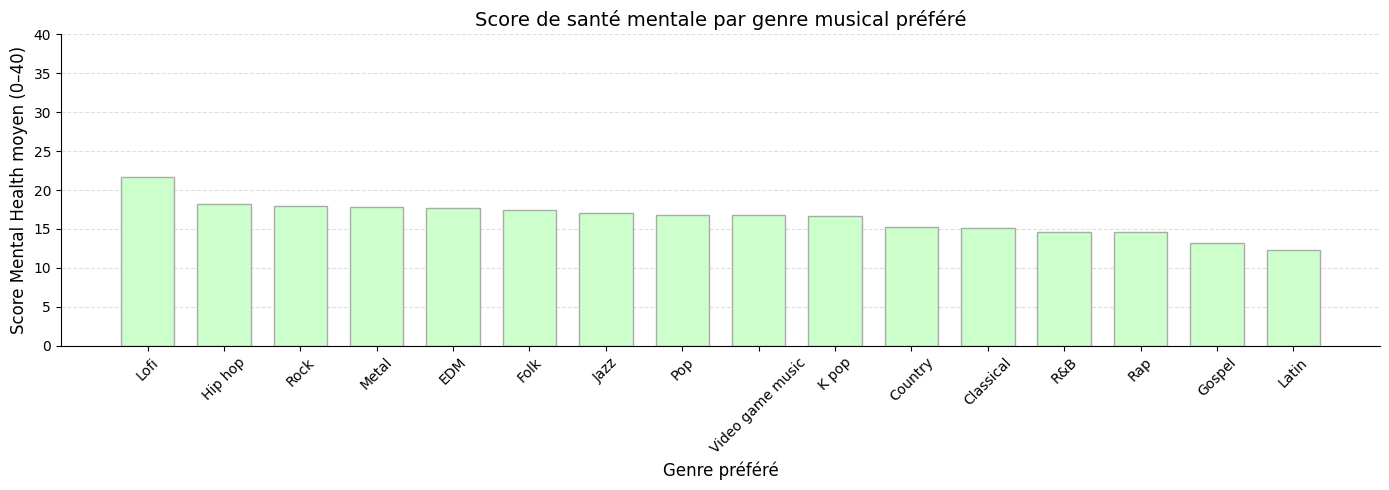

In [18]:
genre_stats = df.groupby('Fav genre')['Mental Health'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.bar(genre_stats.index, genre_stats.values, color='#ccffcc', edgecolor='#aaaaaa', width=0.7)

ax.set_xlabel("Genre préféré", fontsize=12)
ax.set_ylabel("Score Mental Health moyen (0–40)", fontsize=12)
ax.set_title("Score de santé mentale par genre musical préféré", fontsize=14)
ax.set_ylim(0, 40)
ax.tick_params(axis='x', rotation=45)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

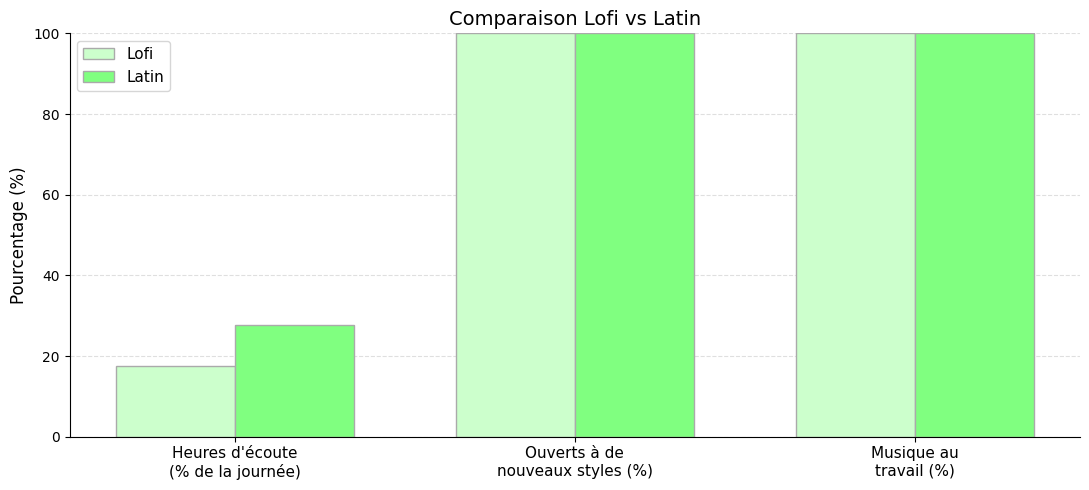

In [22]:
df['Exploratory_num'] = (df['Exploratory'] == 'Yes').astype(int)
df['While working_num'] = (df['While working'] == 'Yes').astype(int)
df['Hours pct'] = df['Hours per day'] / 24 * 100

lofi = df[df['Fav genre'] == 'Lofi']
latin = df[df['Fav genre'] == 'Latin']

metrics = {
    "Heures d'écoute\n(% de la journée)": (lofi['Hours pct'].mean(), latin['Hours pct'].mean()),
    "Ouverts à de\nnouveaux styles (%)": (lofi['Exploratory_num'].mean() * 100, latin['Exploratory_num'].mean() * 100),
    "Musique au\ntravail (%)": (lofi['While working_num'].mean() * 100, latin['While working_num'].mean() * 100),
}

labels = list(metrics.keys())
lofi_vals = [v[0] for v in metrics.values()]
latin_vals = [v[1] for v in metrics.values()]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

bars1 = ax.bar(x - width/2, lofi_vals, width, label='Lofi', color='#ccffcc', edgecolor='#aaaaaa')
bars2 = ax.bar(x + width/2, latin_vals, width, label='Latin', color='#80ff80', edgecolor='#aaaaaa')

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_title('Comparaison Lofi vs Latin', fontsize=14)
ax.set_ylim(0, 100)
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

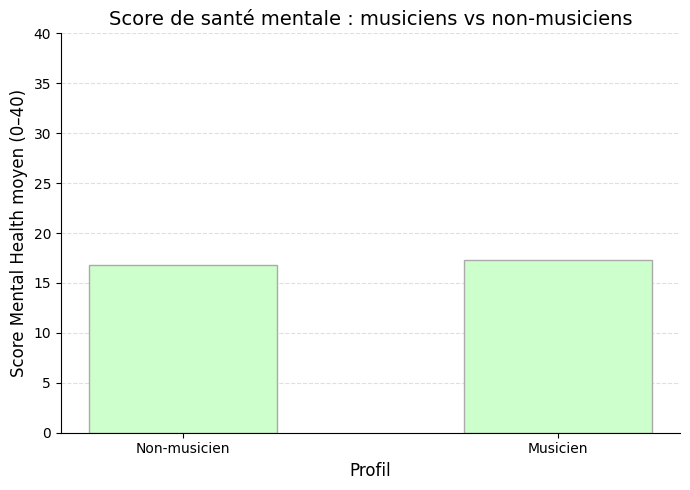

In [20]:
df['Musician'] = ((df['Instrumentalist'] == 'Yes') | (df['Composer'] == 'Yes'))

musician_stats = df.groupby('Musician')['Mental Health'].mean()
musician_stats.index = ['Non-musicien', 'Musicien']

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.bar(musician_stats.index, musician_stats.values, color='#ccffcc', edgecolor='#aaaaaa', width=0.5)

ax.set_xlabel("Profil", fontsize=12)
ax.set_ylabel("Score Mental Health moyen (0–40)", fontsize=12)
ax.set_title("Score de santé mentale : musiciens vs non-musiciens", fontsize=14)
ax.set_ylim(0, 40)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

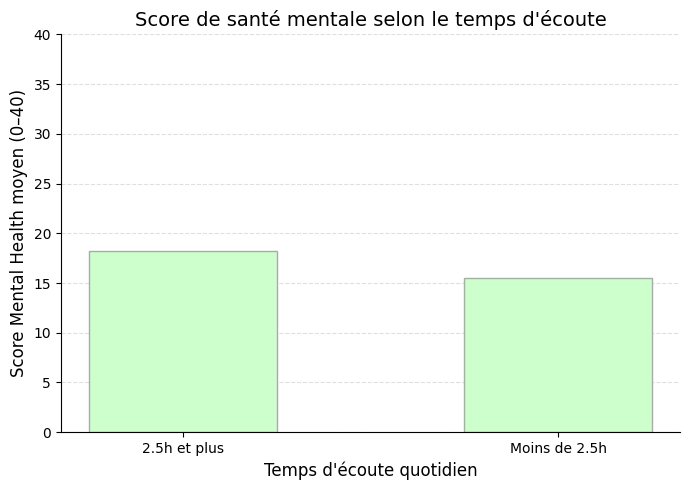

In [21]:
df['Listening Group'] = df['Hours per day'].apply(lambda x: 'Moins de 2.5h' if x < 2.5 else '2.5h et plus')

listening_stats = df.groupby('Listening Group')['Mental Health'].mean()

fig, ax = plt.subplots(figsize=(7, 5))
ax.set_facecolor('white')
fig.patch.set_facecolor('white')

ax.bar(listening_stats.index, listening_stats.values, color='#ccffcc', edgecolor='#aaaaaa', width=0.5)

ax.set_xlabel("Temps d'écoute quotidien", fontsize=12)
ax.set_ylabel("Score Mental Health moyen (0–40)", fontsize=12)
ax.set_title("Score de santé mentale selon le temps d'écoute", fontsize=14)
ax.set_ylim(0, 40)
ax.spines[['top', 'right']].set_visible(False)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()